In [47]:
from typing_extensions import TypedDict, Annotated
from typing import List
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END 
from langchain.chat_models import init_chat_model 
from pydantic import BaseModel 
from operator import add 

llm = init_chat_model("openai:gpt-4o")

In [48]:
class State(TypedDict):
    document: str
    final_summary: str
    summaries: Annotated[list[dict],add]

In [49]:
def summarize_p(args):
    paragraph = args["paragraph"]
    index=args["index"]

    response = llm.invoke(
        f"Write a 3-sentence summary for this paragraph {paragraph}"
    ) # 이 문단을 3문장으로 요약해줘 
    return {
        "summaries" :[
            {
                "summary" :response.content,
                "index" : index
            }
        ] 
    } 

# send command를 써서 summarize_p노드를 원하는 만큼 생성 
def dispatch_summarizers(state :State):
    chunks = state['document'].split("\n\n")
    # 각 청크마다 send command 를 return 
    return [
        Send("summarize_p", {'paragraph': chunk, 'index':index})
        for index, chunk in enumerate(chunks)
    ] # summarize_p 노드를 실행하고 'chunk' dictionary는 chunk를 가지고 'index': index
    # enumerate 는 지금 처리중인 element의 index번호를 준다 .(병렬실행ㅎ이라 순서가 뒤죽박죽이라 정렬필요)

def final_summary(state: State):
    response = llm.invoke(f"Using the following summaries, give me a final one {state["summaries"]}")
    return {
        "final_summary" : response.content
    }

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("summarize_p", summarize_p)   
graph_builder.add_node("final_summary", final_summary)   
 
graph_builder.add_conditional_edges(START, dispatch_summarizers, "summarize_p")   
graph_builder.add_edge("summarize_p" ,"final_summary" ) 
graph_builder.add_edge("final_summary", END ) 

graph = graph_builder.compile()
 

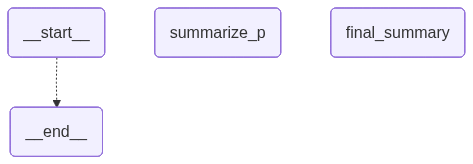

In [51]:
graph

In [52]:
with open("fed_transcript.md","r",encoding="utf-8") as file:
    document = file.read()
#document.split("\n\n")

for chunk in graph.stream(
    {"document":document}, # stream안에 document 넘겨주기  
    stream_mode = "updates"
):
    print(chunk, "\n") # 줄바꿈이 있을 때마다 청크 생성 

{'summarize_p': {'summaries': [{'summary': 'The Federal Open Market Committee is committed to achieving maximum employment and stable prices. Despite a low unemployment rate, job growth has slowed and downside risks to employment have increased, while inflation remains somewhat elevated. In response, the committee has decided to lower the interest rate by a quarter percentage point and continue reducing securities holdings.', 'index': 0}]}} 

{'summarize_p': {'summaries': [{'summary': 'The moderation and growth are primarily due to a deceleration in consumer spending. This slowdown indicates that consumers are being more cautious with their expenditures. As consumer spending is a significant component of economic activity, this change impacts overall economic growth.', 'index': 2}]}} 

{'summarize_p': {'summaries': [{'summary': 'The Federal Reserve has two primary goals for monetary policy: achieving maximum employment and maintaining stable prices. It is dedicated to fostering conditi